# 01 - Exploratory Data Analysis

London short-term rental market, InsideAirbnb. Two snapshot pairs are used:

| pair | t0 (open nights) | t1 (what got taken) | role |
|---|---|---|---|
| summer | 2026-05-24 | 2026-06-19 | primary, defines the simulated market |
| autumn | 2025-09-14 | 2025-10-17 | separates seasonality from booking lead time |

This notebook reads the artifacts produced by `scripts/preprocess.py` and does not recompute anything.
Run `python3 scripts/preprocess.py` first if `data/processed/` is empty.

Booking label: a stay night that was open at t0 and unavailable at t1 was taken during the roughly
26 day window (booking or host block, see the noise section). Nights already closed at t0 carry no
demand signal at the observed price and are excluded.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from airbnb_marl.analysis.plotting import PALETTE, MUTED, INK_SECONDARY, apply_style, new_figure
from airbnb_marl.utils.paths import processed_dir

apply_style()

listings = pd.read_parquet(processed_dir() / 'listings_clean.parquet')
dataset = pd.read_parquet(processed_dir() / 'demand_dataset.parquet')
report = json.loads((processed_dir() / 'preprocess_report.json').read_text())

PAIRS = sorted(dataset['pair_id'].unique())
PAIR_COLOR = {PAIRS[0]: PALETTE[2], PAIRS[1]: PALETTE[0]}
PAIR_NAME = {PAIRS[0]: 'autumn pair (t1 2025-10-17)', PAIRS[1]: 'summer pair (t1 2026-06-19)'}

print(f"primary pair listings: {len(listings):,}   dataset rows: {len(dataset):,}")
print(f"overall booking rate: {dataset['booked'].mean():.3f}")
dataset.groupby('pair_id')['booked'].agg(rows='size', booking_rate='mean').round(3)

primary pair listings: 29,984   dataset rows: 7,155,606
overall booking rate: 0.137


,rows,booking_rate
pair_id,,
2025-10-17,3939188,0.141
2026-06-19,3216418,0.132


## 1. Dataset construction funnel

Listing counts after every filter stage, per pair. These numbers go into the report's data section.

In [2]:
funnel = pd.DataFrame({pid: p['stages'] for pid, p in report['pairs'].items()})
display(funnel)
for pid, p in report['pairs'].items():
    print(f"pair {pid}: price cap {p['price_cap_gbp']} GBP, "
          f"label window {p['labels']['t1_first_date']} to {p['labels']['label_window_end']}")

,2026-06-19,2025-10-17
listings_raw,92638,95627
after_room_type_filter,92255,95241
after_coordinates_filter,92255,95241
after_review_activity_filter,38937,42191
after_present_in_t0_with_price,31483,36219
after_price_sanity,31168,35857
after_min_competitors,30340,34910
after_paused_listing_filter,29984,34263


pair 2026-06-19: price cap 917.54 GBP, label window 2026-06-19 to 2026-12-16
pair 2025-10-17: price cap 775.0 GBP, label window 2025-10-17 to 2026-04-15


## 2. Prices (primary pair, t0 prices)

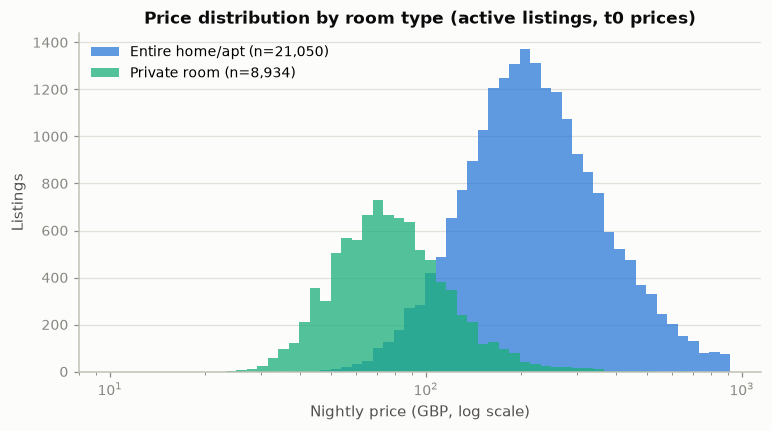

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,21050.0,249.4,136.3,24.7,156.5,215.0,302.5,917.0
Private room,8934.0,85.1,42.4,24.4,58.0,75.0,100.0,628.0


In [3]:
fig, ax = new_figure(8, 4)
bins = np.geomspace(10, listings['price_gbp'].max(), 60)
for i, (room, grp) in enumerate(listings.groupby('room_type', observed=True)):
    ax.hist(grp['price_gbp'], bins=bins, alpha=0.75, label=f'{room} (n={len(grp):,})',
            color=PALETTE[i], edgecolor='none')
ax.set_xscale('log')
ax.set_xlabel('Nightly price (GBP, log scale)')
ax.set_ylabel('Listings')
ax.set_title('Price distribution by room type (active listings, t0 prices)')
ax.legend()
plt.show()

listings.groupby('room_type', observed=True)['price_gbp'].describe().round(1)

## 3. Where are the listings? Cluster density matters for the nearest-competitor design.

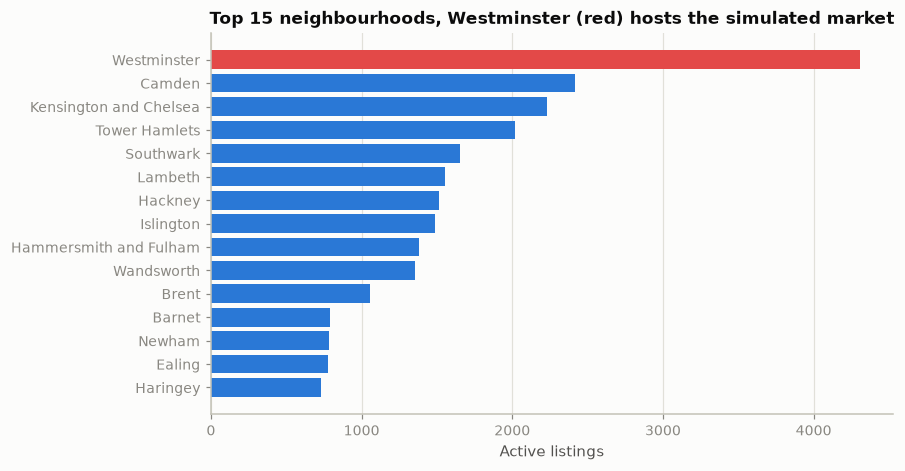

Westminster active listings: 4,311 (3,616 entire homes)


In [4]:
top = listings['neighbourhood_cleansed'].value_counts().head(15)
colors = [PALETTE[5] if n == 'Westminster' else PALETTE[0] for n in top.index]
fig, ax = new_figure(8, 4.5)
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.set_xlabel('Active listings')
ax.set_title('Top 15 neighbourhoods, Westminster (red) hosts the simulated market')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
plt.show()

wm = listings[listings['neighbourhood_cleansed'] == 'Westminster']
print(f"Westminster active listings: {len(wm):,} "
      f"({(wm['room_type'] == 'Entire home/apt').sum():,} entire homes)")

## 4. Lead time vs seasonality, and why we need two pairs

Booking probability falls with distance from the scrape date. Within one pair, lead time and stay
date are perfectly collinear, so a model could not tell December apart from six months out. The
autumn pair breaks the tie: the same stay months show up at two different lead times, which lets
the model carry an explicit log_lead feature and estimate seasonality separately. The simulation
later evaluates demand at a fixed reference lead of 30 days.

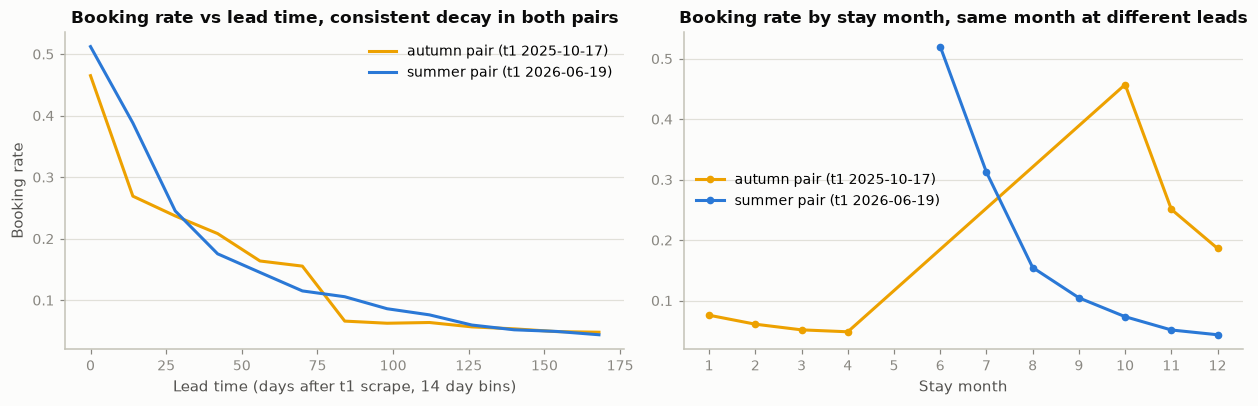

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))

for pid in PAIRS:
    grp = dataset[dataset['pair_id'] == pid]
    lead = grp.groupby(grp['lead_days'] // 14 * 14)['booked'].mean()
    axes[0].plot(lead.index, lead.values, color=PAIR_COLOR[pid], label=PAIR_NAME[pid])
    month = grp.groupby(grp['date'].dt.month)['booked'].mean()
    axes[1].plot(month.index, month.values, color=PAIR_COLOR[pid], marker='o',
                 markersize=4, label=PAIR_NAME[pid])

axes[0].set_xlabel('Lead time (days after t1 scrape, 14 day bins)')
axes[0].set_ylabel('Booking rate')
axes[0].set_title('Booking rate vs lead time, consistent decay in both pairs')
axes[0].legend()

axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel('Stay month')
axes[1].set_title('Booking rate by stay month, same month at different leads')
axes[1].legend()
plt.tight_layout(); plt.show()

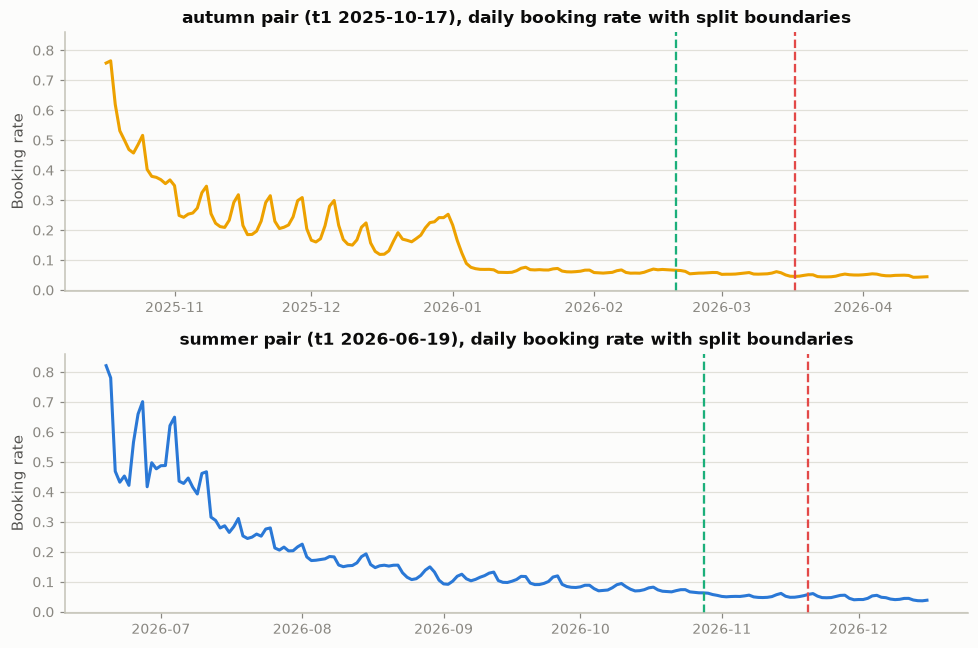

Splits are chronological within each pair (70/15/15):


,rows,booking_rate
test,1049252.0,0.0475
train,5027792.0,0.1737
val,1078562.0,0.0544


Weekend night effect (Fri/Sat): {False: 0.1303, True: 0.1554}


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharey=True)
for ax, pid in zip(axes, PAIRS):
    grp = dataset[dataset['pair_id'] == pid]
    daily = grp.groupby('date')['booked'].mean()
    ax.plot(daily.index, daily.values, color=PAIR_COLOR[pid])
    for key, slot in [('train_end', 1), ('val_end', 5)]:
        boundary = pd.Timestamp(report['split_boundaries'][pid][key])
        ax.axvline(boundary, color=PALETTE[slot], linestyle='--', linewidth=1.5)
    ax.set_title(f'{PAIR_NAME[pid]}, daily booking rate with split boundaries')
    ax.set_ylabel('Booking rate')
plt.tight_layout(); plt.show()

print('Splits are chronological within each pair (70/15/15):')
display(pd.DataFrame(report['split_stats']).T)
print('Weekend night effect (Fri/Sat):',
      dataset.groupby(dataset['is_weekend_night'] > 0)['booked'].mean().round(4).to_dict())

## 5. Label noise: run lengths and paused listings

Real bookings show up as short consecutive runs, roughly the stay length. Host blocks tend to be
long streaks. Listings whose whole open calendar flipped (hosts pausing) were already removed in
preprocessing.

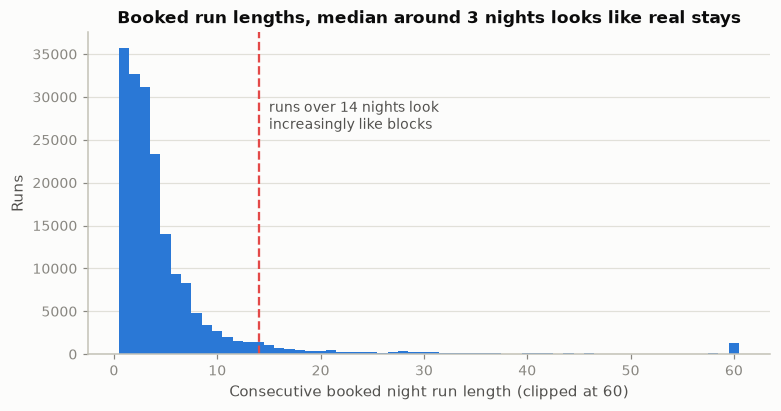

2026-06-19 {"runs": 83127, "median_run_nights": 3.0, "share_nights_in_runs_le_14": 0.6889, "share_nights_in_runs_gt_28": 0.1973}
2026-06-19 {"paused_listings_detected": 356, "paused_nights_removed": 36583, "min_open_nights": 30, "flip_rate_threshold": 0.95}
2025-10-17 {"runs": 98559, "median_run_nights": 3.0, "share_nights_in_runs_le_14": 0.6378, "share_nights_in_runs_gt_28": 0.2479}
2025-10-17 {"paused_listings_detected": 647, "paused_nights_removed": 62309, "min_open_nights": 30, "flip_rate_threshold": 0.95}


In [7]:
booked = dataset.loc[dataset['booked'] == 1, ['listing_id', 'pair_id', 'date']]\
    .sort_values(['pair_id', 'listing_id', 'date'])
new_run = ~(booked['listing_id'].eq(booked['listing_id'].shift())
            & booked['pair_id'].eq(booked['pair_id'].shift())
            & booked['date'].diff().eq(pd.Timedelta(days=1)))
lengths = booked.groupby(new_run.cumsum()).size()

fig, ax = new_figure(8, 3.8)
ax.hist(lengths.clip(upper=60), bins=np.arange(1, 62) - 0.5, color=PALETTE[0])
ax.axvline(14, color=PALETTE[5], linestyle='--', linewidth=1.5)
ax.annotate('runs over 14 nights look\nincreasingly like blocks', (15, ax.get_ylim()[1] * 0.7),
            color=INK_SECONDARY, fontsize=9)
ax.set_xlabel('Consecutive booked night run length (clipped at 60)')
ax.set_ylabel('Runs')
ax.set_title('Booked run lengths, median around 3 nights looks like real stays')
plt.show()

for pid, p in report['pairs'].items():
    print(pid, json.dumps(p['booked_run_lengths']))
    print(pid, json.dumps(p['paused_listings']))

In [8]:
print('Review based volume sanity check, primary pair (see cohort_note):')
print(json.dumps(report['pairs'][PAIRS[1]]['noise'], indent=2))

Review based volume sanity check, primary pair (see cohort_note):
{
  "listings_with_diff_bookings": 25714,
  "diff_booked_nights_total": 425409,
  "review_implied_booked_nights_window_stays": 252586,
  "implied_over_diff_volume_ratio": 0.5937,
  "per_listing_correlation": 0.0266,
  "review_rate_assumed": 0.5,
  "cohort_note": "Reviews posted during the diff window correspond to stays that were mostly BOOKED BEFORE t0, while diff positives are bookings MADE during the window for future stay dates. The cohorts only partially overlap, so this is an aggregate volume sanity check, not a direct noise bound. Run-length analysis and paused-listing exclusion are the primary noise controls."
}


## 6. Competitive clusters (5 nearest, same room type, accommodates within 1; primary pair)

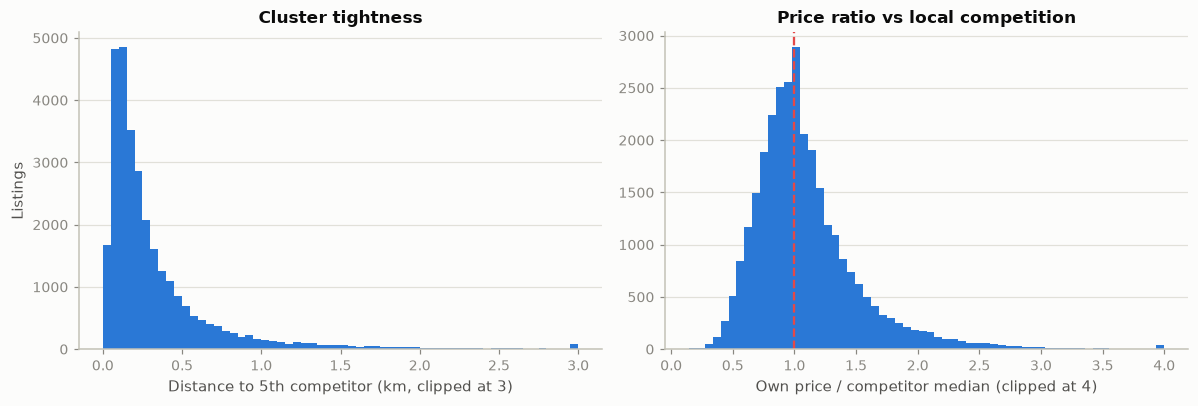

median distance to 5th competitor: 0.20 km
median price ratio: 1.000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(listings['max_competitor_distance_km'].clip(upper=3), bins=60, color=PALETTE[0])
axes[0].set_xlabel('Distance to 5th competitor (km, clipped at 3)')
axes[0].set_ylabel('Listings')
axes[0].set_title('Cluster tightness')

ratio = listings['price_gbp'] / listings['competitor_median_price']
axes[1].hist(ratio.clip(upper=4), bins=60, color=PALETTE[0])
axes[1].axvline(1.0, color=PALETTE[5], linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Own price / competitor median (clipped at 4)')
axes[1].set_title('Price ratio vs local competition')
plt.tight_layout(); plt.show()

print('median distance to 5th competitor:',
      f"{listings['max_competitor_distance_km'].median():.2f} km")
print('median price ratio:', f"{ratio.median():.3f}")

## Findings summary

- 7.16M labelled nights across two seasonally distinct snapshot pairs; overall booking rate 13.7%,
  very consistent between pairs (13.2% summer, 14.1% autumn).
- Primary market: 29,984 active listings (from 92,638 raw); Westminster alone has 4,311, of which 3,616 entire homes.
- Lead time decay replicates in both pairs, and overlapping stay months at different leads make season
  and lead time separable. log_lead is a model feature, fixed at 30 days in the simulation.
- Label noise: median booked run is about 3 nights (stay like); roughly 20 to 25% of booked nights sit in
  runs over 28 nights (likely host blocks). Paused listings were removed per pair.
- Clusters are tight: most listings find 5 comparable competitors within about 1 km, so the
  nearest-competitor market definition makes sense at London's density.
- Weekend nights (Fri/Sat) book at visibly higher rates, so the day of week features carry real signal.